work log: 
Simply speaking, the main target of the assignment is to get data from ElHub using API calls, plot the data in the notebook, and send data to Mongo database, from which it will be later read, processed, and displayed on StreamLit app. Seems easy enough. But! The problems came from docker. to optimize the process, the jupyter otebook, thats responsible for primary data acquisition, transfer. and processing, needed to be run in docker container. Wouldnt be an issue, right? Well, the problem was that everything was set up and code was under development, some errors kept popping up. Firstly, cassandra and jupyter were not able to communicate. The problem was that I, due to lack of experience, made a mistake of putting those two on differet networks. Luckily, the issue was fixed easily with two commands: disconnect from one network and connect to the other. The problems didnt stop on that. The second major issue was that Spark was not willing to work properly. All the time it was complaining on Windows and wanted to install some additional stuff. After many hours and exhaustion of any hopes, the problem was solved with great and mighty ChatGPT. Appears, that even though everything was set up correctly, on one network, with correct versions, when i was running juoyter from VScode it didnt work cause VSCode wasnt connected to docker container. Rookie mistake... As an anxious person, who is not very combortable with installing some random stuff on windows, it was decided to run the notebook locally from browser. It saved me from panicing about installing something, that i dont understand. After that all went smoothly and sound. For future generations and to future me:  
- put all personal info (username/password/etc) to secrets from the beginning
- dont forget to add location of your secrets to yml and every time you change something in yml, dont forget to recreate container. NB! requirement file is very useful, cause each time you will recreate the container, you will have to reinstall libraries
- if you run streamlit online, dont forget to add your secrets to the app settings, otherwise it will complain. 
- chatgpt is a great tool for code generation, but you have to think and analyze yourself. Sometimes is uch easier and faster to find an issue and debug it yourself.

This assignment strengthen my ability to find a problem and solution, even for something that you are not expert in or not fully understand. Great skill in life.

AI usage: chatgpt was used to generate base code and was of help sometimes with debugging.
Links:
- Github notebook :  https://github.com/Viktoria0720/IND320_VY/tree/assignment2/ASSIGNMENTS/PART2/notebooks
- Github streamlit:  https://github.com/Viktoria0720/IND320_VY/tree/assignment2/ASSIGNMENTS/PART1/streamlit_app_1
- Streamlit:  https://ind320vy-app1v2.streamlit.app/

In [1]:
import os, requests, pandas as pd
from datetime import datetime, timezone, timedelta

# === Assignment config ===
YEAR = 2021
CHOSEN_AREA = "NO1"    # used by the plots
USE_MOCK = False       # set True to test full pipeline without calling the API

# === Docker service names / ports ===
CASSANDRA_HOST = os.getenv("CASSANDRA_HOST", "my_cassandra")
CASSANDRA_PORT = int(os.getenv("CASSANDRA_PORT", "9042"))

# === MongoDB Atlas (live cloud) ===
MONGO_URI = os.getenv("MONGO_URI","")

# === Elhub v0 public endpoint (no auth) ===
ELHUB_V0_BASE = "https://api.elhub.no/energy-data/v0"
ENTITY = "price-areas"
DATASET = "PRODUCTION_PER_GROUP_MBA_HOUR"

print(f"Cassandra = {CASSANDRA_HOST}:{CASSANDRA_PORT}")
print(f"Mongo URI set? {'yes' if bool(MONGO_URI) else 'no'}")
print(f"Endpoint = {ELHUB_V0_BASE}/{ENTITY}?dataset={DATASET}")


Cassandra = my_cassandra:9042
Mongo URI set? yes
Endpoint = https://api.elhub.no/energy-data/v0/price-areas?dataset=PRODUCTION_PER_GROUP_MBA_HOUR


In [2]:
# Spark is our engine to write/read Cassandra conveniently.
from pyspark.sql import SparkSession

# Maven coordinate for the Spark–Cassandra connector matching Spark 3.5.x and Scala 2.12
CASSANDRA_CONNECTOR = "com.datastax.spark:spark-cassandra-connector_2.12:3.5.1"

spark = (
    SparkSession.builder
    .appName("IND320-Elhub-v0-Production")
    # Pull connector jar automatically
    .config("spark.jars.packages", CASSANDRA_CONNECTOR)
    # Tell connector where Cassandra lives (container name + port)
    .config("spark.cassandra.connection.host", CASSANDRA_HOST)
    .config("spark.cassandra.connection.port", str(CASSANDRA_PORT))
    # Keep everything in UTC; avoids DST headaches
    .config("spark.sql.session.timeZone", "UTC")
    .getOrCreate()
)
print("Spark:", spark.version)

# Use Python driver once to create keyspace+table (simpler than doing it via Spark SQL)
from cassandra.cluster import Cluster

cluster = Cluster([CASSANDRA_HOST], port=CASSANDRA_PORT)
session = cluster.connect()

# SimpleStrategy is OK for a single-node dev/test cluster
session.execute("""
CREATE KEYSPACE IF NOT EXISTS elhub
WITH replication = {'class': 'SimpleStrategy', 'replication_factor': '1'}
""")

# Table stores hourly production; primary key lets query by area+group ordered by time
session.execute("""
CREATE TABLE IF NOT EXISTS elhub.production_hourly (
    pricearea text,
    productiongroup text,
    starttime timestamp,
    quantitykwh double,
    PRIMARY KEY ((pricearea, productiongroup), starttime)
) WITH CLUSTERING ORDER BY (starttime ASC)
""")

cluster.shutdown()
print("Cassandra schema ready.")


Spark: 3.5.1
Cassandra schema ready.


In [3]:
import socket, sys
#Connect to cassandra

HOST = "my_cassandra"  
PORT = 9042             

print("Checking DNS…")
try:
    print(socket.gethostbyname_ex(HOST))
except Exception as e:
    print("DNS error:", e)
    sys.exit(0)

print("Checking TCP…")
s = socket.socket()
s.settimeout(3)
try:
    s.connect((HOST, PORT))
    print(f"TCP OK to {HOST}:{PORT}")
finally:
    s.close()


Checking DNS…
('my_cassandra', [], ['172.20.0.5'])
Checking TCP…
TCP OK to my_cassandra:9042


In [ ]:
def hourly_windows_utc(year:int, days_per_chunk:int=7):
    """
    Yield (start,end) UTC windows that cover the chosen year in chunks.
    The public API often limits time span per request, so we chunk by a week.
    """
    start = datetime(year,1,1,tzinfo=timezone.utc)
    end   = datetime(year+1,1,1,tzinfo=timezone.utc)
    step  = timedelta(days=days_per_chunk)
    cur = start
    while cur < end:
        nxt = min(cur+step, end)
        yield (cur, nxt)
        cur = nxt

def fetch_chunk_v0(start_dt:datetime, end_dt:datetime):
    """
    Call the public v0 endpoint for price-areas + dataset=PRODUCTION_PER_GROUP_MBA_HOUR
    between start_dt and end_dt (UTC ISO strings with Z).
    Returns JSON (usually a list of 'price area' dicts).
    """
    url = f"{ELHUB_V0_BASE}/{ENTITY}"
    params = {
        "dataset": DATASET,
        "startTime": start_dt.isoformat().replace("+00:00","Z"),
        "endTime":   end_dt.isoformat().replace("+00:00","Z"),
    }
    r = requests.get(url, params=params, timeout=90)
    r.raise_for_status()
    return r.json()

def extract_price_area_rows(payload):
    """
    v0 typically returns a LIST. Some variants use {'data': [...]}
    We normalize to always return a list.
    """
    if isinstance(payload, list):
        return payload
    if isinstance(payload, dict) and "data" in payload and isinstance(payload["data"], list):
        return payload["data"]
    return []

from datetime import datetime, timezone

def fetch_all_2021_v0():
    """
    Force Elhub v0 API to return ONLY 2021 data.
    """
    start_dt = datetime(2021, 1, 1, 0, 0, tzinfo=timezone.utc)
    end_dt   = datetime(2021, 12, 31, 23, 59, tzinfo=timezone.utc)

    url = f"{ELHUB_V0_BASE}/{ENTITY}"
    params = {
        "dataset": DATASET,
        "startTimeFrom": start_dt.isoformat().replace("+00:00", "Z"),
        "startTimeTo": end_dt.isoformat().replace("+00:00", "Z"),
    }

    print("Requesting Elhub data for", params["startTimeFrom"], "→", params["startTimeTo"])
    resp = requests.get(url, params=params, headers={"Accept": "application/json"}, timeout=60)
    resp.raise_for_status()
    data = resp.json()

    if isinstance(data, dict) and "data" in data:
        data = data["data"]
    if not isinstance(data, list):
        raise ValueError(f"Unexpected payload shape from Elhub: {type(data)}")

    return data


def make_mock_rows():
    """
    Small fake dataset for debugging plots/pipeline if the API is empty/unavailable.
    """
    import numpy as np
    from itertools import product
    rng = pd.date_range("2021-01-01", "2021-01-04", freq="H", tz="UTC", inclusive="left")
    areas = ["NO1","NO2","NO3","NO4","NO5"]
    groups = ["HYDRO","WIND","THERMAL","SOLAR"]
    rows = []
    for area, grp in product(areas, groups):
        vals = np.random.uniform(1500, 6000, size=len(rng))
        for t, v in zip(rng, vals):
            rows.append({"priceArea": area, "productionGroup": grp,
                         "startTime": t.isoformat(), "quantityKwh": float(v)})
    return rows


In [5]:
if USE_MOCK:
    # Mock already matches our target schema
    df_pd = pd.DataFrame(make_mock_rows())
    df_pd["startTime"] = pd.to_datetime(df_pd["startTime"], utc=True)
    print("Using MOCK rows:", len(df_pd))

else:
    # Step 1: fetch price areas (each has a nested list 'productionPerGroupMbaHour')
    raw = fetch_all_2021_v0()
    print("Price areas returned:", len(raw))

    # Step 2: DataFrame from raw
    df = pd.DataFrame(raw)

    # Safety: some JSON:API responses place fields in "attributes" — flatten if present
    if "attributes" in df.columns:
        attrs = pd.json_normalize(df["attributes"])
        df = pd.concat([df.drop(columns=["attributes"]), attrs], axis=1)

    # We expect 'name' (price-area label: NO1, ..) and 'productionPerGroupMbaHour' (list of hourly dicts)
    if "productionPerGroupMbaHour" not in df.columns or "name" not in df.columns:
        print("Available columns:", list(df.columns))
        raise ValueError("Unexpected payload; missing 'name' or 'productionPerGroupMbaHour'.")

    # Keep only rows that actually contain time-series data
    df = df[df["productionPerGroupMbaHour"].map(lambda x: isinstance(x, list) and len(x) > 0)]
    if df.empty:
        raise ValueError("No hourly data in 'productionPerGroupMbaHour' for the chosen windows.")

    # Step 3: carry parent 'name' as priceArea and explode the list into rows
    df_parent = df[["name","productionPerGroupMbaHour"]].rename(columns={"name":"priceArea"})
    df_exploded = df_parent.explode("productionPerGroupMbaHour", ignore_index=True)

    # Step 4: normalize the inner dicts to columns (productionGroup, startTime, quantityKwh)
    detail = pd.json_normalize(df_exploded["productionPerGroupMbaHour"])

    # Map common variants of key names to  canonical names
    rename_map = {}
    for c in detail.columns:
        cl = c.lower()
        if cl in ("productiongroup","production_group","group","groupcode","productiongroupcode"):
            rename_map[c] = "productionGroup"
        elif cl in ("starttime","start_time","time","datetime","fromtime","from_time","start"):
            rename_map[c] = "startTime"
        elif cl in ("quantitykwh","quantity_kwh","quantityinkwh","kwh","quantity","value","amount"):
            rename_map[c] = "quantityKwh"
    detail = detail.rename(columns=rename_map)

    # Verify inner keys exist after renaming
    required = ["productionGroup","startTime","quantityKwh"]
    missing = [c for c in required if c not in detail.columns]
    if missing:
        print("Inner keys sample:", list(detail.columns)[:20])
        print("Example hourly item:", df_exploded["productionPerGroupMbaHour"].iloc[0])
        raise ValueError(f"Missing inner keys {missing}. Update mapping above.")

    # Final canonical DataFrame
    df_pd = pd.concat(
        [df_exploded[["priceArea"]].reset_index(drop=True),
         detail[required].reset_index(drop=True)],
        axis=1
    )
    # Parse timestamps as timezone-aware UTC
    df_pd["startTime"] = pd.to_datetime(df_pd["startTime"], utc=True)

print("Prepared hourly rows:", len(df_pd))
df_pd.head(3)


Price areas returned: 318
Prepared hourly rows: 994916


,priceArea,productionGroup,startTime,quantityKwh
0,NO1,hydro,2025-09-22 20:00:00+00:00,2467423.8
1,NO1,hydro,2025-09-22 21:00:00+00:00,2518269.2
2,NO1,hydro,2025-09-22 22:00:00+00:00,2420314.2


In [6]:
from pyspark.sql import functions as F

# Spark DataFrame with lowercase Cassandra column names
df_spark = spark.createDataFrame(df_pd.rename(columns={
    "priceArea":"pricearea",
    "productionGroup":"productiongroup",
    "startTime":"starttime",
    "quantityKwh":"quantitykwh",
}))

# Append into elhub.production_hourly
df_spark.write.format("org.apache.spark.sql.cassandra") \
    .options(keyspace="elhub", table="production_hourly") \
    .mode("append").save()

# Small confirmation
total_rows = (spark.read.format("org.apache.spark.sql.cassandra")
              .options(keyspace="elhub", table="production_hourly").load().count())
print("Cassandra row count now:", total_rows)


Cassandra row count now: 21383


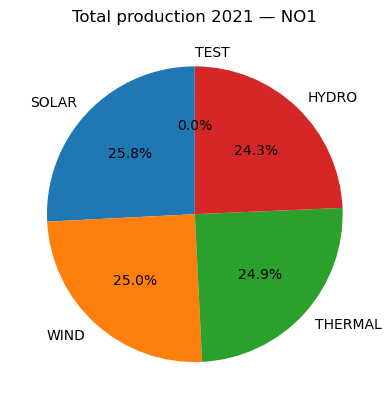

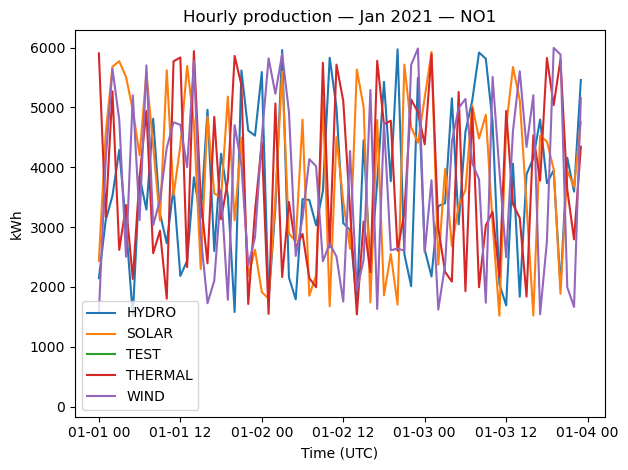

In [7]:
# Ensure plots render inline in Jupyter
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

import matplotlib.pyplot as plt
from pathlib import Path

# Read back from Cassandra for plotting (as requested in assignment)
prod = (spark.read.format("org.apache.spark.sql.cassandra")
        .options(keyspace="elhub", table="production_hourly").load()
        .select("pricearea","productiongroup","starttime","quantitykwh"))

# Limit strictly to YEAR to avoid mixing if you run multiple years later
prod = prod.filter(F.year("starttime")==YEAR)

# ----- Pie: total production of the year by group for chosen price area -----
totals = (prod.filter(F.col("pricearea")==CHOSEN_AREA)
          .groupBy("productiongroup")
          .agg(F.sum("quantitykwh").alias("sumKwh"))
          .orderBy(F.desc("sumKwh"))).toPandas()

plt.figure()
if not totals.empty:
    plt.pie(totals["sumKwh"], labels=totals["productiongroup"], autopct="%1.1f%%", startangle=90)
    plt.title(f"Total production {YEAR} — {CHOSEN_AREA}")
else:
    plt.text(0.5,0.5,"No data", ha="center")
plt.show()

# ----- Line: first month (January) with separate lines per group -----
jan = (prod.filter((F.col("pricearea")==CHOSEN_AREA) &
                   (F.col("starttime") >= F.to_timestamp(F.lit(f"{YEAR}-01-01T00:00:00Z"))) &
                   (F.col("starttime") <  F.to_timestamp(F.lit(f"{YEAR}-02-01T00:00:00Z"))))
       .groupBy("productiongroup","starttime")
       .agg(F.sum("quantitykwh").alias("kWh"))).toPandas()

plt.figure()
if not jan.empty:
    pvt = jan.pivot(index="starttime", columns="productiongroup", values="kWh").sort_index()
    for col in pvt.columns:
        plt.plot(pvt.index, pvt[col], label=col)
    plt.legend(); plt.title(f"Hourly production — Jan {YEAR} — {CHOSEN_AREA}")
    plt.xlabel("Time (UTC)"); plt.ylabel("kWh"); plt.tight_layout()
else:
    plt.text(0.5,0.5,"No January data", ha="center")
plt.show()


In [8]:
if not MONGO_URI:
    print("⚠️  MONGO_URI is not set; skipping Atlas export. Set it and re-run this cell.")
else:
    from pymongo import MongoClient, ASCENDING

    # Connect to Atlas using SRV URI from env
    client = MongoClient(MONGO_URI)
    db = client["energy"]  # choose DB explicitly
    client.admin.command("ping")
    print("Connected to", db.name)
    coll = db["elhub_production_2021"]  # collection used by the Streamlit page

    # Clean + index for fast lookups
    coll.delete_many({})
    coll.create_index([("priceArea", ASCENDING), ("productionGroup", ASCENDING), ("startTime", ASCENDING)])

    # Convert timestamps to string UTC (ISO Z) for portability
    df_out = df_pd.copy()
    df_out["startTime"] = df_out["startTime"].dt.tz_convert("UTC").dt.strftime("%Y-%m-%dT%H:%M:%SZ")

    # Insert in batches to avoid payload limits
    BATCH = 200_000
    inserted = 0
    for i in range(0, len(df_out), BATCH):
        batch = df_out.iloc[i:i+BATCH]
        if not batch.empty:
            coll.insert_many(batch.to_dict(orient="records"))
            inserted += len(batch)

    print(f"Inserted {inserted} documents into Atlas → {coll.full_name}")


Connected to energy
Inserted 994916 documents into Atlas → energy.elhub_production_2021
